# Notes
* Near 100% accuracy in the paper is achieved by data-driven threshold-based approach(Not ML-based).
* "_The grid chosen for the simulations and extraction of the results was the IEEE 13 node test feeder_". The data in the paper is generated via Simulink on benchmark grids (IEEE 13-node for fault classification, CIGRE European LV benchmark for fault detection)(Not real data) https://cmte.ieee.org/pes-testfeeders/resources/
* The real data used here has noise and sometimes ambiguous subcategories
* Fault detection CatBoost in paper gets 97.61% accuracy, fault classification(which is ~100%) is threshold-based as mentioned above.

# Idea for this project:
* Creating a "classification pipeline": CatBoost will be used first to classify between first 4 main categories since the accuracy of this is very high 96-something%.
* Then for each other subcategory train a separate model(to be honest RandomForest/CatBoost/ and XG-boost are pretty much the same. XGBoost was just slightly(0.01) better at least for my parameters).

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

### Training CatBoost for 4 categories

0:	learn: 0.8139678	test: 0.8139115	best: 0.8139115 (0)	total: 389ms	remaining: 6m 29s
20:	learn: 0.9076570	test: 0.9072539	best: 0.9072539 (20)	total: 5.38s	remaining: 4m 10s
40:	learn: 0.9203902	test: 0.9198391	best: 0.9198391 (40)	total: 10.7s	remaining: 4m 10s
60:	learn: 0.9264229	test: 0.9258829	best: 0.9258829 (60)	total: 16.1s	remaining: 4m 8s
80:	learn: 0.9320486	test: 0.9314694	best: 0.9314694 (80)	total: 21s	remaining: 3m 57s
100:	learn: 0.9364559	test: 0.9355897	best: 0.9355897 (100)	total: 27.6s	remaining: 4m 5s
120:	learn: 0.9401055	test: 0.9394187	best: 0.9394187 (120)	total: 33.6s	remaining: 4m 4s
140:	learn: 0.9435242	test: 0.9426647	best: 0.9426647 (140)	total: 38.4s	remaining: 3m 53s
160:	learn: 0.9459677	test: 0.9450410	best: 0.9450410 (160)	total: 44.4s	remaining: 3m 51s
180:	learn: 0.9480290	test: 0.9471572	best: 0.9471572 (180)	total: 49.1s	remaining: 3m 42s
200:	learn: 0.9499816	test: 0.9493272	best: 0.9493272 (200)	total: 54.5s	remaining: 3m 36s
220:	learn: 0.95

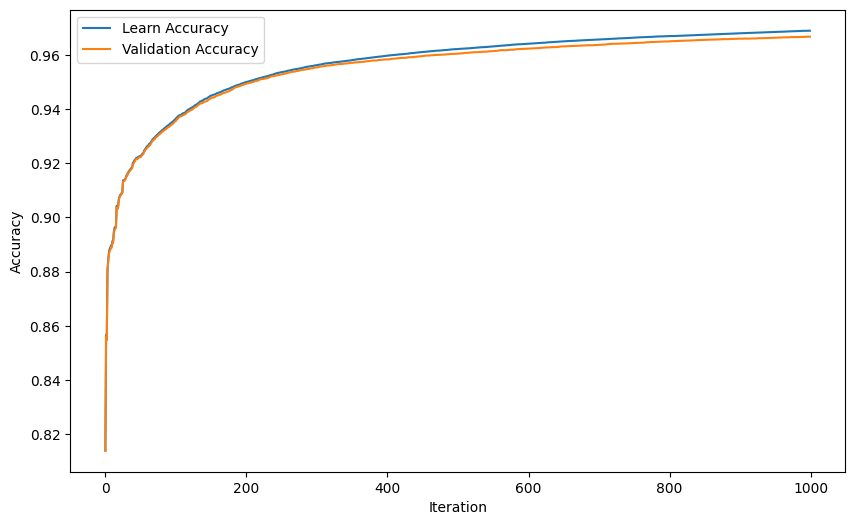

Best Train Accuracy: 0.9688651709574153
Score Test Accuracy: 0.9666829567923099


In [2]:
labeled_dataset = pd.read_csv('data/FiveCats/4Categories_traintest.csv')

train, test = train_test_split(
    labeled_dataset,
    test_size=0.2,
    random_state=1,
    stratify=labeled_dataset['event_type']
)

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']

classifier = CatBoostClassifier(
    iterations=1000,
    max_depth=7,
    random_seed=2,
    learning_rate=0.1,
    eval_metric="Accuracy",
    loss_function="MultiClass",
    early_stopping_rounds=20
)

classifier.fit(
    train_features, train_labels,
    eval_set=(test_features, test_labels),
    verbose=20,
    plot=False
)

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Learn Accuracy')
plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Validation Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
test_score = classifier.score(test_features, test_labels)
print(f"Score Test Accuracy: {test_score}")

classifier.save_model("CatBoost_4Categories", format="cbm")

### Training CatBoost Subcategory

In [10]:
def train_subcategory_model(main_category):
    labeled_dataset = pd.read_csv(f'data/FiveCats/only{main_category}_traintest.csv')
    
    train, test = train_test_split(
        labeled_dataset,
        test_size=0.2,
        random_state=1,
        stratify=labeled_dataset['event_type']
    )
    
    train_features = train.drop(fields_to_drop, axis=1)
    train_labels = train['event_type']
    
    test_features = test.drop(fields_to_drop, axis=1)
    test_labels = test['event_type']
    
    classifier = CatBoostClassifier(
        iterations=500,
        max_depth=7,
        random_seed=2,
        learning_rate=0.1,
        eval_metric="Accuracy",
        loss_function="MultiClass",
        early_stopping_rounds=20
    )
    
    classifier.fit(
        train_features, train_labels,
        eval_set=(test_features, test_labels),
        verbose=20,
        plot=False
    )
    
    plt.figure(figsize=(10, 6))
    plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Learn Accuracy')
    plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Validation Accuracy')
    plt.xlabel('Iteration')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
    
    print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
    test_score = classifier.score(test_features, test_labels)
    print(f"Score Test Accuracy: {test_score}")
    
    classifier.save_model(f"CatBoost_{main_category}", format="cbm")

In [ ]:
#train_subcategory_model(0)
#train_subcategory_model(1)
#train_subcategory_model(2)
train_subcategory_model(3)

0:	learn: 0.9763706	test: 0.9761925	best: 0.9761925 (0)	total: 555ms	remaining: 4m 37s
